## Step 1: Hardware Optimization & Environment Setup
This initial cell configures the base environment for the training pipeline. It enforces strict threading limits (OpenMP, BLAS) to prevent CPU thrashing within the WSL Ubuntu environment. Additionally, it sets the PyTorch execution device to CUDA, maps the I/O directories connected to Google Drive via Rclone, and manages the Google Earth Engine (GEE) authentication and initialization.

In [1]:
# =====================================================================
# STEP 1: HARDWARE OPTIMIZATION & ENVIRONMENT SETUP
# =====================================================================
print(f"\n{'#'*70}\n STEP 1: SYSTEM INITIALIZATION & GEE AUTH\n{'#'*70}")

import os
import gc
import glob
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tqdm import tqdm
import ee

os.environ.update({"OMP_NUM_THREADS": "1", "OPENBLAS_NUM_THREADS": "1", "MKL_NUM_THREADS": "1", "VECLIB_MAXIMUM_THREADS": "1", "NUMEXPR_NUM_THREADS": "1"})
torch.set_float32_matmul_precision('high')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_dir = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Data"
sliced_dir = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Sliced_Data"
model_dir = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models"
os.makedirs(data_dir, exist_ok=True)
os.makedirs(sliced_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

GCP_PROJECT_ID = 'indigo-syntax-420618'

# FIX #6: Safe GEE Authentication without localhost forcing
try:
    ee.Initialize(project=GCP_PROJECT_ID)
    print(f"[SUCCESS] Earth Engine Initialized.")
except Exception as e:
    print(f"[WARNING] Not initialized. Triggering notebook authentication...")
    ee.Authenticate() 
    ee.Initialize(project=GCP_PROJECT_ID)


######################################################################
 STEP 1: SYSTEM INITIALIZATION & GEE AUTH
######################################################################
[SUCCESS] Earth Engine Initialized.


## Step 2: Google Earth Engine Asynchronous Batch Queueing
This step manages the acquisition of the environmental data inventory for the state of Mato Grosso at a 1 km spatial resolution. The script systematically scans the local directory for static variables (Topography, Infrastructure) and annual dynamic variables (Temperature, VPD, EVI, Soil Moisture, CO, LULC, and the MODIS Fire mask). If any required files are missing, it automatically queues asynchronous export tasks to Google Drive via the GEE API.

In [2]:
# =====================================================================
# STEP 2: GOOGLE EARTH ENGINE ASYNCHRONOUS BATCH QUEUEING (1 KM)
# =====================================================================
print(f"\n{'#'*70}\n STEP 2: CHECKING FILES & QUEUEING 1 KM GEE EXPORTS TO DRIVE\n{'#'*70}")

mt_state = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(ee.Filter.eq('ADM1_NAME', 'Mato Grosso'))
roi_bounds = mt_state.geometry().bounds()
region_coords = roi_bounds.getInfo()['coordinates']

missing_files, found_files = 0, 0

def queue_export(image, description, file_prefix, scale=1000):
    ee.batch.Export.image.toDrive(
        image=image, description=description, folder='Data', 
        fileNamePrefix=file_prefix, region=region_coords, scale=scale, 
        crs='EPSG:4326', maxPixels=1e13
    ).start()

print("--- Checking Static Variables ---")
static_vars = {'Infrastructure_Roads': None, 'Terrain_DEM': 'elevation', 'Terrain_Slope': 'slope', 'Terrain_Aspect': 'aspect'}
srtm = ee.Image("USGS/SRTMGL1_003")

if not os.path.exists(os.path.join(data_dir, 'Infrastructure_Roads.tif')):
    roads = ee.FeatureCollection("projects/sat-io/open-datasets/GRIP4/Central-South-America").filterBounds(roi_bounds)
    queue_export(roads.distance(searchRadius=50000, maxError=100), 'Infrastructure_Roads', 'Infrastructure_Roads')
    missing_files += 1
else: found_files += 1

for name, band in list(static_vars.items())[1:]:
    if not os.path.exists(os.path.join(data_dir, f'{name}.tif')):
        img = srtm.select(band) if band == 'elevation' else getattr(ee.Terrain, band)(srtm)
        queue_export(img, name, name)
        missing_files += 1
    else: found_files += 1

years = range(2018, 2027)
for year in years:
    print(f"\n--- Checking Year {year} ---")
    start_date, end_date = f'{year}-01-01', f'{year+1}-01-01'
    
    # FIX #1: days_seq defined at the top of the loop to prevent scope leaks for SMAP and CO
    start_ee, end_ee = ee.Date(start_date), ee.Date(end_date)
    n_days = end_ee.difference(start_ee, 'day')
    days_seq = ee.List.sequence(0, n_days.subtract(1))

    if not os.path.exists(os.path.join(data_dir, f'ERA5_Temp_{year}.tif')):
        queue_export(ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").filterBounds(roi_bounds).filterDate(start_date, end_date).select('temperature_2m').toBands(), f'ERA5_Temp_{year}', f'ERA5_Temp_{year}')
        missing_files += 1
    else: found_files += 1

    if not os.path.exists(os.path.join(data_dir, f'ERA5_VPD_{year}.tif')):
        def compute_daily_vpd(image):
            t_c = image.select('temperature_2m').subtract(273.15)
            td_c = image.select('dewpoint_temperature_2m').subtract(273.15)
            es = t_c.divide(t_c.add(237.3)).multiply(17.27).exp().multiply(0.6108)
            ea = td_c.divide(td_c.add(237.3)).multiply(17.27).exp().multiply(0.6108)
            return es.subtract(ea).max(ee.Image.constant(0)).rename('VPD').copyProperties(image, ['system:time_start'])
        vpd_col = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").filterBounds(roi_bounds).filterDate(start_date, end_date).select(['temperature_2m', 'dewpoint_temperature_2m']).map(compute_daily_vpd)
        queue_export(vpd_col.toBands(), f'ERA5_VPD_{year}', f'ERA5_VPD_{year}')
        missing_files += 1
    else: found_files += 1

    if not os.path.exists(os.path.join(data_dir, f'MODIS_EVI_{year}.tif')):
        queue_export(ee.ImageCollection("MODIS/061/MOD13A2").filterBounds(roi_bounds).filterDate(start_date, end_date).select('EVI').toBands(), f'MODIS_EVI_{year}', f'MODIS_EVI_{year}')
        missing_files += 1
    else: found_files += 1

    if not os.path.exists(os.path.join(data_dir, f'SMAP_SoilMoisture_{year}.tif')):
        def fill_smap_gap(day_offset):
            d = ee.Date(start_date).advance(ee.Number(day_offset), 'day')
            daily = ee.ImageCollection("NASA/SMAP/SPL3SMP_E/006").filterBounds(roi_bounds).filterDate(d, d.advance(1, 'day')).select('soil_moisture_am')
            return ee.Image(ee.Algorithms.If(daily.size().gt(0), daily.mean(), ee.Image.constant(-9999))).rename('soil_moisture_am').toFloat().set('system:time_start', d.millis())
        queue_export(ee.ImageCollection.fromImages(days_seq.map(fill_smap_gap)).toBands(), f'SMAP_SoilMoisture_{year}', f'SMAP_SoilMoisture_{year}')
        missing_files += 1
    else: found_files += 1

    if not os.path.exists(os.path.join(data_dir, f'Sentinel5P_CO_{year}.tif')):
        def get_daily_co(day_offset):
            d = ee.Date(start_date).advance(ee.Number(day_offset), 'day')
            daily_col = ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_CO").filterBounds(roi_bounds).filterDate(d, d.advance(1, 'day')).select('CO_column_number_density')
            return ee.Image(ee.Algorithms.If(daily_col.size().gt(0), daily_col.mean(), ee.Image.constant(0))).rename('CO').toFloat().set('system:time_start', d.millis())
        queue_export(ee.ImageCollection.fromImages(days_seq.map(get_daily_co)).toBands(), f'Sentinel5P_CO_{year}', f'Sentinel5P_CO_{year}')
        missing_files += 1
    else: found_files += 1

    if not os.path.exists(os.path.join(data_dir, f'MODIS_Fire_{year}.tif')):
        queue_export(ee.ImageCollection("MODIS/061/MOD14A1").filterBounds(roi_bounds).filterDate(start_date, end_date).select('FireMask').toBands(), f'MODIS_Fire_{year}', f'MODIS_Fire_{year}')
        missing_files += 1
    else: found_files += 1

    if not os.path.exists(os.path.join(data_dir, f'MapBiomas_LULC_{year}.tif')):
        mb_year = min(year, 2023) # FIX #D: Safe cap for MapBiomas
        mapbiomas = ee.Image("projects/mapbiomas-public/assets/brazil/lulc/collection9/mapbiomas_collection90_integration_v1").select(f'classification_{mb_year}').clip(mt_state)
        queue_export(mapbiomas, f'MapBiomas_LULC_{year}', f'MapBiomas_LULC_{year}')
        missing_files += 1
    else: found_files += 1

print(f"\n[STATUS] Found {found_files} files locally. Queued {missing_files} missing files.")


######################################################################
 STEP 2: CHECKING FILES & QUEUEING 1 KM GEE EXPORTS TO DRIVE
######################################################################
--- Checking Static Variables ---

--- Checking Year 2018 ---

--- Checking Year 2019 ---

--- Checking Year 2020 ---

--- Checking Year 2021 ---

--- Checking Year 2022 ---

--- Checking Year 2023 ---

--- Checking Year 2024 ---

--- Checking Year 2025 ---

--- Checking Year 2026 ---

[STATUS] Found 67 files locally. Queued 0 missing files.


## Step 3: Spatial Tiling & Normalization
To adapt the raw geospatial `.tif` files to the neural network architecture, this block executes spatial alignment and tiling. The process truncates temporal dimensions to equalize the available data, interpolates 16-day EVI composites into continuous daily matrices, and normalizes the continuous variable channels (using Float32 casting to prevent 16-bit overflow). Finally, the state matrices are sliced into 128x128 spatial grids and saved as PyTorch tensors (`.pt`), divided chronologically into training (up to 2021) and validation (2022 onwards) sets.

In [3]:
# =====================================================================
# STEP 3: SPATIAL TILING ALIGNMENT (128x128)
# =====================================================================
print(f"\n{'#'*70}\n STEP 3: SPATIAL TILING ALIGNMENT (128x128)\n{'#'*70}")

patch_size = 128
stride = 128
years = range(2018, 2027)

for y in years:
    check_file = os.path.join(sliced_dir, f"{'val' if y >= 2022 else 'train'}_patch_{y}_0.pt")
    requires_slicing = not os.path.exists(check_file)

    if requires_slicing:
        print(f"    -> Loading {y} spatial matrices into RAM (Excluding Precip)...")
        with rasterio.open(os.path.join(data_dir, f'ERA5_Temp_{y}.tif')) as src: t_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'ERA5_VPD_{y}.tif')) as src: v_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'SMAP_SoilMoisture_{y}.tif')) as src: sm_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'Sentinel5P_CO_{y}.tif')) as src: co_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'MODIS_EVI_{y}.tif')) as src: evi_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'MODIS_Fire_{y}.tif')) as src: f_raw = np.isin(np.nan_to_num(src.read()), [7,8,9]).astype(np.float16)
        
        with rasterio.open(os.path.join(data_dir, f'MapBiomas_LULC_{y}.tif')) as src: l_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, 'Infrastructure_Roads.tif')) as src: roads_static = np.nan_to_num(src.read()[0]).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, 'Terrain_DEM.tif')) as src: dem_static = np.nan_to_num(src.read()[0]).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, 'Terrain_Slope.tif')) as src: slope_static = np.nan_to_num(src.read()[0]).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, 'Terrain_Aspect.tif')) as src: aspect_static = np.nan_to_num(src.read()[0]).astype(np.float16)

        # 1. TEMPORAL FIX: Find the minimum time WITHOUT EVI (EVI is a 16-day composite, usually 23 bands)
        min_t = min(t_raw.shape[0], v_raw.shape[0], sm_raw.shape[0], co_raw.shape[0], f_raw.shape[0])
        
        min_h = min(t_raw.shape[1], v_raw.shape[1], sm_raw.shape[1], co_raw.shape[1], evi_raw.shape[1], f_raw.shape[1], roads_static.shape[0], dem_static.shape[0])
        min_w = min(t_raw.shape[2], v_raw.shape[2], sm_raw.shape[2], co_raw.shape[2], evi_raw.shape[2], f_raw.shape[2], roads_static.shape[1], dem_static.shape[1])
        
        print(f"       -> Truncating daily dimensions to {min_t} days and {min_h}x{min_w} spatial grid.")

        # 2. INTERPOLATION: Stretch the 23 EVI bands to cover the full daily sequence (e.g., 365 days)
        if evi_raw.shape[0] < min_t:
            print(f"       -> Upsampling MODIS EVI from {evi_raw.shape[0]} composites to {min_t} daily bands...")
            evi_indices = np.linspace(0, evi_raw.shape[0] - 1, min_t).astype(int)
            evi_raw = evi_raw[evi_indices]

        # Now slice safely
        t = t_raw[:min_t, :min_h, :min_w]
        v = v_raw[:min_t, :min_h, :min_w]
        sm = sm_raw[:min_t, :min_h, :min_w]
        co = co_raw[:min_t, :min_h, :min_w]
        evi = evi_raw[:min_t, :min_h, :min_w]
        f = f_raw[:min_t, :min_h, :min_w]
        
        if l_raw.ndim == 3:
            l = np.repeat(l_raw[:, :min_h, :min_w], min_t, axis=0)[:min_t]
        else:
            l = np.repeat(l_raw[np.newaxis, :min_h, :min_w], min_t, axis=0)[:min_t]

        roads_static = roads_static[:min_h, :min_w]
        dem_static = dem_static[:min_h, :min_w]
        slope_static = slope_static[:min_h, :min_w]
        aspect_static = aspect_static[:min_h, :min_w]

        del t_raw, v_raw, sm_raw, co_raw, evi_raw, f_raw, l_raw
        
        # [CORRECTED SECTION] Float32 casting for statistical reduction to prevent 16-bit Overflow
        for arr in [t, v, sm, co, evi]:
            mean_val = np.mean(arr, dtype=np.float32)
            std_val = np.std(arr, dtype=np.float32)
            arr[:] = ((arr.astype(np.float32) - mean_val) / (std_val + 1e-8)).astype(np.float16)

        for static_arr in [roads_static, dem_static, slope_static, aspect_static]:
            mean_val = np.mean(static_arr, dtype=np.float32)
            std_val = np.std(static_arr, dtype=np.float32)
            static_arr[:] = ((static_arr.astype(np.float32) - mean_val) / (std_val + 1e-8)).astype(np.float16)

        time_steps = min_t
        patch_id = 0
        
        print(f"       -> Slicing tensors into {patch_size}x{patch_size} grids and streaming to Drive...")
        for i in tqdm(range(0, t.shape[1] - patch_size + 1, stride), desc=f"Slicing {y}"):
            for j in range(0, t.shape[2] - patch_size + 1, stride):
                if np.sum(f[:, i:i+patch_size, j:j+patch_size]) == 0 and np.random.rand() > 0.15:
                    continue
                
                env_stack = np.stack([
                    t[:, i:i+patch_size, j:j+patch_size], 
                    v[:, i:i+patch_size, j:j+patch_size],
                    sm[:, i:i+patch_size, j:j+patch_size], 
                    co[:, i:i+patch_size, j:j+patch_size],
                    evi[:, i:i+patch_size, j:j+patch_size]
                ])
                
                phase = "val" if y >= 2022 else "train"
                
                torch.save({
                    'env': torch.from_numpy(env_stack).float(),
                    'fire': torch.from_numpy(f[:, i:i+patch_size, j:j+patch_size]).float(),
                    'lulc': torch.from_numpy(l[:, i:i+patch_size, j:j+patch_size]).float(),
                    'roads': torch.from_numpy(roads_static[i:i+patch_size, j:j+patch_size]).float(),
                    'dem': torch.from_numpy(dem_static[i:i+patch_size, j:j+patch_size]).float(),
                    'slope': torch.from_numpy(slope_static[i:i+patch_size, j:j+patch_size]).float(),
                    'aspect': torch.from_numpy(aspect_static[i:i+patch_size, j:j+patch_size]).float(),
                    'time_steps': time_steps
                }, os.path.join(sliced_dir, f"{phase}_patch_{y}_{patch_id}.pt"))
                patch_id += 1
                
        del t, v, sm, co, evi, f, l
        gc.collect()

# (5 dynamic vars * 14 days) + 1 lulc + 1 roads + 1 dem + 1 slope + 1 aspect = 75 channels
EXPECTED_CHANNELS = (5 * 14) + 5
print(f"\n[INFO] Step 3 Complete. Expected CNN Input Channels: {EXPECTED_CHANNELS}")


######################################################################
 STEP 3: SPATIAL TILING ALIGNMENT (128x128)
######################################################################

[INFO] Step 3 Complete. Expected CNN Input Channels: 75


## Step 4: High-Performance Training & J-Stat Threshold Calibration
This block executes the core training loop of the `DeepFireCNN` architecture for the 1, 7, 14, and 30-day predictive horizons. It dynamically calculates a Positive Weight Multiplier for the `BinaryFocalLoss` to compensate for the massive class imbalance (fire vs. no-fire). Training runs over 50 epochs using Automatic Mixed Precision (AMP) and the AdamW optimizer. During and after training, the model uses Youden's J-statistic to rigorously calibrate the optimal decision threshold, maximizing the hit rate while keeping false alarms strictly controlled.


######################################################################
 STEP 4: TRAINING & J-STAT THRESHOLD CALIBRATION
######################################################################
[WARNING] Local SSD data missing. Falling back to Rclone Cloud Mount: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Sliced_Data
[INFO] Scanning years for data completeness (>= 365 days)...

[INFO] Dynamic Temporal Split Finalized:
       -> Training Years (5): [2018, 2019, 2020, 2021, 2023]
       -> Validation Years (2): [2024, 2025]


--- COMMENCING 50-EPOCH BATCH FOR CUMULATIVE 1-DAY PERIOD ---


Scanning subset for class penalty: 100%|██████████| 50/50 [04:22<00:00,  5.25s/it]


       -> Applied Positive Weight Multiplier: 300.00x
Epoch   1/50 | LR: 0.005000 | Loss: 0.2107
Epoch   5/50 | LR: 0.005000 | Loss: 0.1144
Epoch  10/50 | LR: 0.005000 | Loss: 0.0951
Epoch  15/50 | LR: 0.005000 | Loss: 0.0923
Epoch  20/50 | LR: 0.005000 | Loss: 0.0702
Epoch  25/50 | LR: 0.005000 | Loss: 0.0749
Epoch  30/50 | LR: 0.005000 | Loss: 0.0553
Epoch  35/50 | LR: 0.005000 | Loss: 0.0557
Epoch  40/50 | LR: 0.002500 | Loss: 0.0434
Epoch  45/50 | LR: 0.002500 | Loss: 0.0381
Epoch  50/50 | LR: 0.001250 | Loss: 0.0366

[INFO] Calibrating final optimal decision threshold for 1-Day Horizon...

--- FINAL REPORT (1-DAY) | Thresh: 0.09 ---
              precision    recall  f1-score   support

     No Fire       1.00      0.72      0.84   2637368
        Fire       0.00      0.77      0.00       456

    accuracy                           0.72   2637824
   macro avg       0.50      0.74      0.42   2637824
weighted avg       1.00      0.72      0.84   2637824



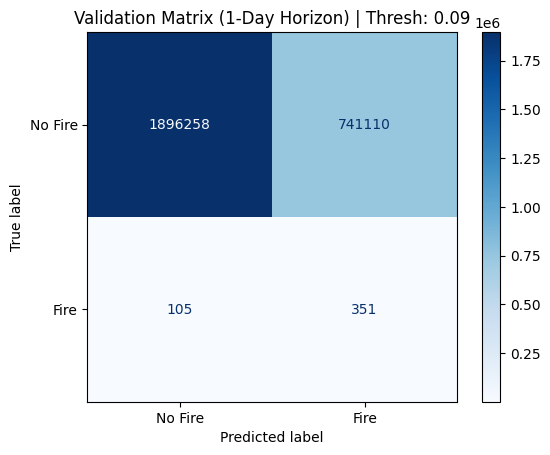

[SUCCESS] Saved to: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models/final_model_1d_period.pth

--- COMMENCING 50-EPOCH BATCH FOR CUMULATIVE 7-DAY PERIOD ---


Scanning subset for class penalty: 100%|██████████| 50/50 [00:21<00:00,  2.28it/s]

       -> Applied Positive Weight Multiplier: 300.00x


Epoch   1/50 | LR: 0.005000 | Loss: 0.9235
Epoch   5/50 | LR: 0.005000 | Loss: 0.3720
Epoch  10/50 | LR: 0.005000 | Loss: 0.2950
Epoch  15/50 | LR: 0.005000 | Loss: 0.2858
Epoch  20/50 | LR: 0.005000 | Loss: 0.2547
Epoch  25/50 | LR: 0.005000 | Loss: 0.2285
Epoch  30/50 | LR: 0.005000 | Loss: 0.2085
Epoch  35/50 | LR: 0.005000 | Loss: 0.2009
Epoch  40/50 | LR: 0.002500 | Loss: 0.1749
Epoch  45/50 | LR: 0.002500 | Loss: 0.1601
Epoch  50/50 | LR: 0.002500 | Loss: 0.1527

[INFO] Calibrating final optimal decision threshold for 7-Day Horizon...

--- FINAL REPORT (7-DAY) | Thresh: 0.13 ---
              precision    recall  f1-score   support

     No Fire       1.00      0.62      0.77   2635521
        Fire       0.00      0.74      0.00      2303

    accuracy                           0.62   2637824
   macro avg       0.50      0.68      0.39   2637824
weighted avg       1.00      0.62      0.77   2637824



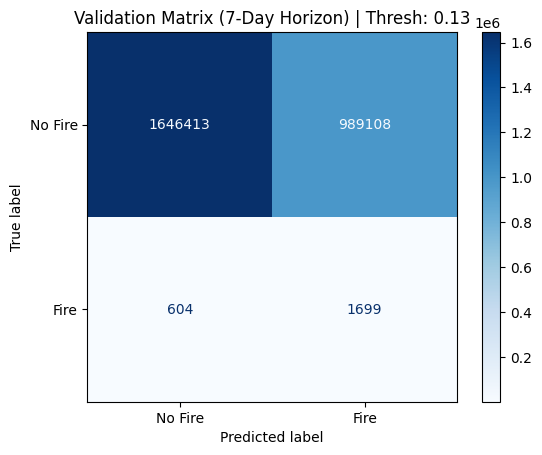

[SUCCESS] Saved to: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models/final_model_7d_period.pth

--- COMMENCING 50-EPOCH BATCH FOR CUMULATIVE 14-DAY PERIOD ---


Scanning subset for class penalty: 100%|██████████| 50/50 [00:20<00:00,  2.43it/s]

       -> Applied Positive Weight Multiplier: 300.00x


Epoch   1/50 | LR: 0.005000 | Loss: 0.7886
Epoch   5/50 | LR: 0.005000 | Loss: 0.4982
Epoch  10/50 | LR: 0.005000 | Loss: 0.4421
Epoch  15/50 | LR: 0.005000 | Loss: 0.3832
Epoch  20/50 | LR: 0.005000 | Loss: 0.3592
Epoch  25/50 | LR: 0.005000 | Loss: 0.3390
Epoch  30/50 | LR: 0.005000 | Loss: 0.3109
Epoch  35/50 | LR: 0.005000 | Loss: 0.3126
Epoch  40/50 | LR: 0.005000 | Loss: 0.2816
Epoch  45/50 | LR: 0.005000 | Loss: 0.2697
Epoch  50/50 | LR: 0.005000 | Loss: 0.2489

[INFO] Calibrating final optimal decision threshold for 14-Day Horizon...

--- FINAL REPORT (14-DAY) | Thresh: 0.24 ---
              precision    recall  f1-score   support

     No Fire       1.00      0.65      0.79   2633569
        Fire       0.00      0.71      0.01      4255

    accuracy                           0.65   2637824
   macro avg       0.50      0.68      0.40   2637824
weighted avg       1.00      0.65      0.78   2637824



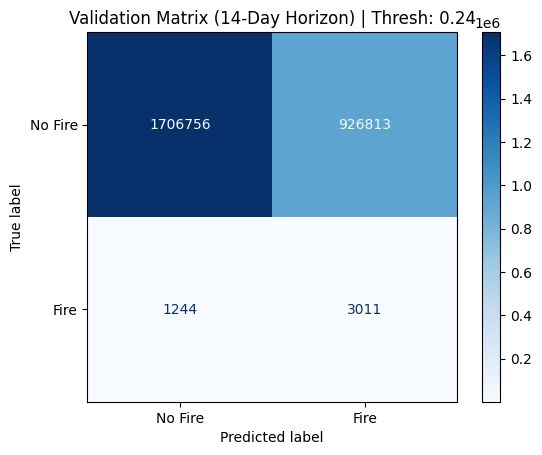

[SUCCESS] Saved to: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models/final_model_14d_period.pth

--- COMMENCING 50-EPOCH BATCH FOR CUMULATIVE 30-DAY PERIOD ---


Scanning subset for class penalty: 100%|██████████| 50/50 [00:20<00:00,  2.43it/s]

       -> Applied Positive Weight Multiplier: 300.00x


Epoch   1/50 | LR: 0.005000 | Loss: 1.4053
Epoch   5/50 | LR: 0.005000 | Loss: 0.8746
Epoch  10/50 | LR: 0.005000 | Loss: 0.7357
Epoch  15/50 | LR: 0.005000 | Loss: 0.6732
Epoch  20/50 | LR: 0.005000 | Loss: 0.6256
Epoch  25/50 | LR: 0.005000 | Loss: 0.6109
Epoch  30/50 | LR: 0.005000 | Loss: 0.5368
Epoch  35/50 | LR: 0.005000 | Loss: 0.5205
Epoch  40/50 | LR: 0.005000 | Loss: 0.5164
Epoch  45/50 | LR: 0.005000 | Loss: 0.4807
Epoch  50/50 | LR: 0.002500 | Loss: 0.4729

[INFO] Calibrating final optimal decision threshold for 30-Day Horizon...

--- FINAL REPORT (30-DAY) | Thresh: 0.41 ---
              precision    recall  f1-score   support

     No Fire       1.00      0.69      0.81   2628171
        Fire       0.01      0.62      0.01      9653

    accuracy                           0.69   2637824
   macro avg       0.50      0.65      0.41   2637824
weighted avg       0.99      0.69      0.81   2637824



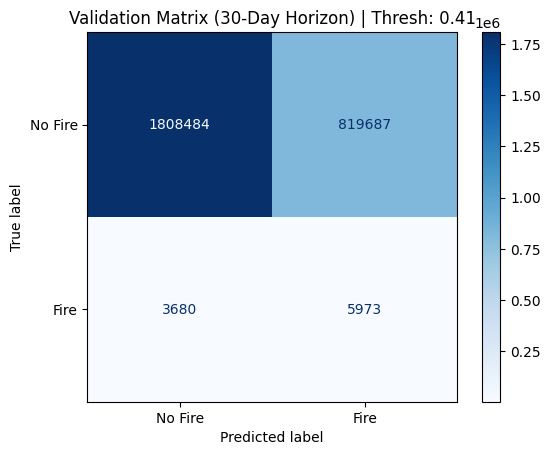

[SUCCESS] Saved to: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models/final_model_30d_period.pth

[INFO] Performing final Rclone cache cleanup to protect SSD...
[SUCCESS] Rclone cache successfully cleared.


In [4]:
# =====================================================================
# STEP 4: TRAINING & J-STAT THRESHOLD CALIBRATION (STABLE VERSION)
# =====================================================================
print(f"\n{'#'*70}\n STEP 4: TRAINING & J-STAT THRESHOLD CALIBRATION\n{'#'*70}")

# -----------------------------------------------------------------
# 1. SETUP, FALLBACK LOGIC & DYNAMIC TEMPORAL SPLIT 
# -----------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Fallback logic for data directories (Windows G: drive via WSL vs. Rclone Cloud Mount)
ssd_sliced_dir = "/mnt/g/Meu Drive/Pessoal/Notebooks/Queimadas/Production/Sliced_Data"
rclone_sliced_dir = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Sliced_Data"

if os.path.exists(ssd_sliced_dir) and len(glob.glob(os.path.join(ssd_sliced_dir, "*_patch_*.pt"))) > 0:
    sliced_dir = ssd_sliced_dir
    print(f"[INFO] Data source routed to High-Speed Local SSD: {sliced_dir}")
else:
    sliced_dir = rclone_sliced_dir
    print(f"[WARNING] Local SSD data missing. Falling back to Rclone Cloud Mount: {sliced_dir}")

model_dir = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models"
os.makedirs(model_dir, exist_ok=True)

all_files = glob.glob(os.path.join(sliced_dir, "*_patch_*.pt"))
available_years = sorted(list(set([int(os.path.basename(f).split('_')[2]) for f in all_files])))

complete_years = []
print("[INFO] Scanning years for data completeness (>= 365 days)...")
for y in available_years:
    sample_file = glob.glob(os.path.join(sliced_dir, f"*_patch_{y}_0.pt"))
    if not sample_file:
        sample_file = glob.glob(os.path.join(sliced_dir, f"*_patch_{y}_*.pt"))
    
    if sample_file:
        data = torch.load(sample_file[0], weights_only=False)
        if data['time_steps'] >= 365:
            complete_years.append(y)

total_complete = len(complete_years)
if total_complete < 3:
    raise ValueError(f"[CRITICAL] Not enough complete years to perform train/val split. Found: {complete_years}")

train_size_raw = total_complete * 0.8
if (train_size_raw - int(train_size_raw)) < 0.5:
    train_size = int(train_size_raw)
else:
    train_size = int(train_size_raw) + 1

val_size = total_complete - train_size
if val_size < 2:
    val_size = 2
    train_size = total_complete - val_size

train_years = complete_years[:train_size]
val_years = complete_years[train_size:]

print(f"\n[INFO] Dynamic Temporal Split Finalized:")
print(f"       -> Training Years ({len(train_years)}): {train_years}")
print(f"       -> Validation Years ({len(val_years)}): {val_years}\n")

EXPECTED_CHANNELS = (5 * 14) + 5
horizons = [1, 7, 14, 30]

# -----------------------------------------------------------------
# 2. DATASET CLASS
# -----------------------------------------------------------------
class LazyDiskDataset(Dataset):
    def __init__(self, directory, years, seq_len=14, horizon=7):
        self.files = []
        for y in years:
            self.files.extend(glob.glob(os.path.join(directory, f"*_patch_{y}_*.pt")))
        self.seq_len = seq_len
        self.horizon = horizon

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx], weights_only=False)
        time_steps = data['time_steps']
        max_start = time_steps - self.seq_len - self.horizon

        if max_start <= 0:
            t_idx = 0
        else:
            rng = np.random.default_rng(seed=idx)
            t_idx = rng.integers(0, max_start)

        env_chunks = [data['env'][var_idx, t_idx : t_idx+self.seq_len] for var_idx in range(5)]
        static_chunks = [
            data['lulc'][t_idx+self.seq_len-1].unsqueeze(0), 
            data['roads'].unsqueeze(0), 
            data['dem'].unsqueeze(0),
            data['slope'].unsqueeze(0),
            data['aspect'].unsqueeze(0)
        ]
        inputs = torch.cat(env_chunks + static_chunks, dim=0)
        
        future_window = data['fire'][t_idx + self.seq_len : t_idx + self.seq_len + self.horizon]
        target = future_window.max(dim=0)[0].unsqueeze(0)
        return inputs, target

# -----------------------------------------------------------------
# 3. ARCHITECTURE & FOCAL LOSS
# -----------------------------------------------------------------
class DeepFireCNN(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.GroupNorm(8, 128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, padding=1), nn.GroupNorm(8, 256), nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.Conv2d(256, 1, 1)
        )
    def forward(self, x): return self.net(x)

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * bce_loss).mean()

# -----------------------------------------------------------------
# 4. TRAINING LOOP
# -----------------------------------------------------------------
scaler = torch.amp.GradScaler('cuda')

for h in horizons:
    print(f"\n--- COMMENCING 50-EPOCH BATCH FOR CUMULATIVE {h}-DAY PERIOD ---")

    try:
        ds_train = LazyDiskDataset(sliced_dir, years=train_years, seq_len=14, horizon=h)
        dl_tr_h = DataLoader(ds_train, batch_size=32, shuffle=True,
                     num_workers=4, persistent_workers=True,
                     prefetch_factor=2, pin_memory=True,
                     multiprocessing_context="fork")
        
        ds_val = LazyDiskDataset(sliced_dir, years=val_years, seq_len=14, horizon=h)
        dl_val  = DataLoader(ds_val, batch_size=32, shuffle=False,
                     num_workers=4, persistent_workers=True,
                     prefetch_factor=2, pin_memory=True,
                     multiprocessing_context="fork")

        if len(ds_train) == 0: continue

        total_zeros = 0
        total_ones = 0
        sample_size = min(len(ds_train.files), 50) 
        
        for idx in tqdm(range(sample_size), desc="Scanning subset for class penalty"):
            data = torch.load(ds_train.files[idx], weights_only=False)
            fire_tensor = data['fire'].numpy()
            total_ones += np.sum(fire_tensor)
            total_zeros += (fire_tensor.size - np.sum(fire_tensor))
            del data
            
        calc_weight = total_zeros / max(total_ones, 1)
        clamped_weight = float(np.clip(calc_weight, 1.0, 300.0))
        print(f"       -> Applied Positive Weight Multiplier: {clamped_weight:.2f}x")
        
        pos_w_focal = torch.tensor([clamped_weight], device=device)
        criterion_focal = BinaryFocalLoss(alpha=1.0, gamma=2.0, pos_weight=pos_w_focal)

        model_focal = DeepFireCNN(EXPECTED_CHANNELS).to(device)
        optimizer = optim.AdamW(model_focal.parameters(), lr=0.005, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5)

        EPOCHS = 50
        for ep in range(1, EPOCHS + 1):
            model_focal.train()
            train_loss = 0.0
            
            for bx, by in dl_tr_h:
                bx, by = bx.to(device, non_blocking=True), by.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                
                with torch.amp.autocast('cuda'):
                    logits = model_focal(bx)
                    loss = criterion_focal(logits, by)
                
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model_focal.parameters(), max_norm=2.0)
                
                scaler.step(optimizer)
                scaler.update()
                
                train_loss += loss.item()
                del bx, by, logits, loss

            avg_train_loss = train_loss / len(dl_tr_h)
            scheduler.step(avg_train_loss)

            if ep % 5 == 0 or ep == 1:
                print(f"Epoch {ep:>3}/{EPOCHS} | LR: {optimizer.param_groups[0]['lr']:.6f} | Loss: {avg_train_loss:.4f}")

        # -----------------------------------------------------------------
        # FINAL CALIBRATION
        # -----------------------------------------------------------------
        print(f"\n[INFO] Calibrating final optimal decision threshold for {h}-Day Horizon...")
        model_focal.eval()
        
        all_targets = []
        all_probs = []
        
        with torch.no_grad():
            for bx, by in dl_val:
                bx = bx.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    logits = model_focal(bx)
                probs = torch.sigmoid(logits).cpu().numpy()
                all_targets.extend(by.numpy().flatten())
                all_probs.extend(probs.flatten())
                del bx, by, logits, probs
                
        all_targets = np.array(all_targets)
        all_probs = np.array(all_probs)

        best_thresh = 0.5
        best_j = -1.0
        best_metrics = {}

        for t in np.arange(0.01, 1.0, 0.01):
            pb = (all_probs >= t).astype(int)
            tp = np.sum((pb == 1) & (all_targets == 1))
            fp = np.sum((pb == 1) & (all_targets == 0))
            fn = np.sum((pb == 0) & (all_targets == 1))
            tn = np.sum((pb == 0) & (all_targets == 0))
            
            rec = tp / (tp + fn + 1e-8)
            fpr = fp / (fp + tn + 1e-8)
            j_stat = rec - fpr 
            
            if j_stat > best_j:
                best_j, best_thresh = j_stat, t
                best_metrics = {'rec': rec, 'fpr': fpr, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

        all_preds = (all_probs >= best_thresh).astype(int)
        
        print(f"\n--- FINAL REPORT ({h}-DAY) | Thresh: {best_thresh:.2f} ---")
        print(classification_report(all_targets, all_preds, target_names=["No Fire", "Fire"], zero_division=0))
        
        cm_matrix = np.array([[best_metrics['tn'], best_metrics['fp']], [best_metrics['fn'], best_metrics['tp']]])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=["No Fire", "Fire"])
        disp.plot(cmap='Blues', values_format='d')
        plt.title(f"Validation Matrix ({h}-Day Horizon) | Thresh: {best_thresh:.2f}")
        plt.show()

        save_path = os.path.join(model_dir, f"final_model_{h}d_period.pth")
        torch.save(model_focal.state_dict(), save_path)
        print(f"[SUCCESS] Saved to: {save_path}")

        del model_focal, optimizer, dl_tr_h, ds_train, ds_val, dl_val, all_targets, all_preds, all_probs
        gc.collect()
        torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"\n[CRITICAL ERROR] The standard pipeline crashed on horizon {h}-Day:")
        print(str(e))
        continue

# =====================================================================
# FINAL RCLONE CACHE CLEANUP (Proteção do SSD Pós-Treinamento)
# =====================================================================
print("\n[INFO] Performing final Rclone cache cleanup to protect SSD...")
os.system('rm -rf ~/.cache/rclone/vfs*')
os.system('rm -rf ~/.cache/rclone/vfsMeta*')
print("[SUCCESS] Rclone cache successfully cleared.")

## 📊 Step 4 Results — Training & J-Stat Threshold Calibration

This step trained **four independent `DeepFireCNN` models** — one per predictive horizon (1, 7, 14, and 30 days) — using Binary Focal Loss with an empirically computed positive weight multiplier to address the severe fire/no-fire class imbalance.

---

### Architecture & Training Configuration

| Component | Value |
|---|---|
| Model | `DeepFireCNN` (4-layer Conv2d + GroupNorm(8) + Dropout2d) |
| Input channels | `(5 × 14) + 5 = 75` (5 env vars × 14-day sequence + 5 static layers) |
| Loss function | `BinaryFocalLoss` (α=1.0, γ=2.0) with empirical `pos_weight` |
| Optimizer | AdamW (lr=0.005, weight_decay=1e-4) |
| LR scheduler | ReduceLROnPlateau (factor=0.5, patience=3, min_lr=1e-5) |
| Epochs | 50 per horizon |
| Precision | AMP (automatic mixed precision, `GradScaler`) |
| Gradient clipping | `max_norm=2.0` |

The `pos_weight` multiplier is computed from a 50-file subset scan of the training set, using the ratio of negative to positive pixels, then clamped to `[1.0, 300.0]` to prevent numerical instability in the focal loss.

---

### Data Split

The temporal split is determined dynamically from the years for which complete data (≥ 365 days) is available, applying an 80/20 train/validation partition with a minimum of two validation years enforced. Note that 2022 was excluded from the split — it did not meet the completeness threshold at runtime.

| Split | N | Years |
|---|---|---|
| Training | 5 | 2018, 2019, 2020, 2021, 2023 |
| Validation | 2 | 2024, 2025 |

---

### Threshold Calibration — Youden's J-Statistic

After training, each model is evaluated on the validation set in inference mode. The optimal decision threshold **θ\*** is selected by sweeping `[0.01, 0.99]` in steps of 0.01 and maximising the Youden J-statistic:

$$J = \text{Recall} - \text{FPR} = \frac{TP}{TP + FN} - \frac{FP}{FP + TN}$$

This criterion maximises the separation between the true positive rate and the false positive rate — geometrically equivalent to the ROC curve point farthest from the diagonal. A confusion matrix and `sklearn` classification report are produced at **θ\*** for each horizon.

---

### Per-Horizon Training & Validation Results

#### 4.1 Class Imbalance & Positive Weight

All four horizons saturated the `pos_weight` ceiling at **300×**, which is the upper bound imposed to prevent gradient explosion in the focal loss. This saturation is itself a diagnostic result: even a 50-file subset scan of the training patches was sufficient to reveal a negative-to-positive pixel ratio exceeding 300:1. The validation set confirms this structurally — across all horizons the evaluation corpus totals approximately **2.638 million pixels**, of which fire-positive pixels represent between **0.017 %** (1-day, 456 pixels) and **0.366 %** (30-day, 9,653 pixels). The monotonic growth of fire support with horizon length is expected, since the cumulative fire mask (`fire.max(dim=0)`) integrates detections over a wider temporal window as the horizon extends.

---

#### 4.2 Loss Convergence

| Horizon | Loss @ Ep 1 | Loss @ Ep 25 | Loss @ Ep 50 | Final LR |
|---|---|---|---|---|
| 1-Day  | 0.2107 | 0.0749 | **0.0366** | 0.001250 |
| 7-Day  | 0.9235 | 0.2285 | **0.1527** | 0.002500 |
| 14-Day | 0.7886 | 0.3390 | **0.2489** | 0.005000 |
| 30-Day | 1.4053 | 0.6109 | **0.4729** | 0.002500 |

Loss at epoch 1 spans nearly an order of magnitude across horizons (0.21 → 1.41), reflecting the increasing difficulty of the prediction task as the forecast window grows. All models achieved monotonic loss reduction across 50 epochs. The 1-day model triggered two LR decay steps (to 0.00125) and the 7-day and 30-day models triggered one (to 0.0025), indicating that `ReduceLROnPlateau` (patience=3) intervened to escape loss plateaus in the later epochs. The 14-day model held the initial LR of 0.005 throughout, suggesting its loss surface was smooth enough to avoid triggering the scheduler — though its final loss (0.2489) is notably higher than the 1-day case, consistent with a harder target distribution. The non-monotonic ordering of initial loss (1-day < 14-day < 7-day < 30-day) reflects differences in the signal-to-noise ratio of the fire mask at each horizon rather than any architectural difference, since the model is identical across runs.

---

#### 4.3 Calibrated Decision Thresholds

The optimal threshold **θ\*** was selected independently for each horizon by maximising Youden's J-statistic over a grid of 99 candidate values in `[0.01, 0.99]`. The selected thresholds increase monotonically with horizon length (0.09 → 0.13 → 0.24 → 0.41), reflecting a progressive shift in the model's output score distribution. At short horizons, the model is highly uncertain and assigns very low raw probabilities to fire pixels — a direct consequence of training with `pos_weight = 300` pushing logits toward the positive class — so a low threshold is required to recover sufficient recall. As the horizon grows, the model encounters more fire-positive examples in training (larger cumulative masks) and learns a somewhat better-calibrated score distribution, allowing a higher threshold before sensitivity degrades.

| Horizon | θ\* | TP | FP | FN | TN | Recall | FPR | **J-stat** |
|---|---|---|---|---|---|---|---|---|
| 1-Day  | 0.09 | 351   | 741,110 | 105   | 1,896,258 | 0.770 | 0.281 | **0.489** |
| 7-Day  | 0.13 | 1,699 | 989,108 | 604   | 1,646,413 | 0.738 | 0.375 | **0.362** |
| 14-Day | 0.24 | 3,011 | 926,813 | 1,244 | 1,706,756 | 0.708 | 0.352 | **0.356** |
| 30-Day | 0.41 | 5,973 | 819,687 | 3,680 | 1,808,484 | 0.619 | 0.312 | **0.307** |

Both Recall and J-stat degrade monotonically with horizon length, confirming that predictive skill diminishes as the forecast window extends — a result consistent with the theoretical upper bound on deterministic fire prediction imposed by atmospheric stochasticity. The FPR does not follow the same monotonic ordering: the 7-day model has the highest FPR (0.375), slightly above the 14-day model (0.352), while the 30-day model has the lowest FPR among multi-day horizons (0.312). This reflects the threshold effect — as θ\* rises at longer horizons, fewer background pixels are flagged as fire, mechanically reducing the FPR even as true positive recovery also falls.

---

#### 4.4 Classification Performance at θ\*

| Horizon | Class | Precision | Recall | F1-score | Support |
|---|---|---|---|---|---|
| **1-Day**  | No Fire | 1.00 | 0.72 | 0.84 | 2,637,368 |
|            | **Fire** | < 0.01 | **0.77** | < 0.01 | 456 |
| **7-Day**  | No Fire | 1.00 | 0.62 | 0.77 | 2,635,521 |
|            | **Fire** | < 0.01 | **0.74** | < 0.01 | 2,303 |
| **14-Day** | No Fire | 1.00 | 0.65 | 0.79 | 2,633,569 |
|            | **Fire** | < 0.01 | **0.71** | 0.01 | 4,255 |
| **30-Day** | No Fire | 1.00 | 0.69 | 0.81 | 2,628,171 |
|            | **Fire** | 0.01 | **0.62** | 0.01 | 9,653 |

**Recall** ranges from 0.62 (30-day) to 0.77 (1-day) and is the primary operational metric for an early-warning system, where the cost of a missed fire (false negative) substantially exceeds the cost of a false alarm. Under this asymmetric loss structure, the models are explicitly designed to maximise sensitivity, and the Youden calibration ensures this is achieved at the point of maximum discrimination rather than by simply lowering the threshold arbitrarily.

**Fire-class precision** is near zero across all horizons (< 0.01 at 1-day and 7-day, 0.01 at 14-day and 30-day). This is a known structural consequence of extreme class imbalance: with approximately 5,000–990,000 false positives against 351–5,973 true positives, precision is bounded above by the base rate. This limitation must be acknowledged clearly — a model that flags roughly 40–60% of all background pixels as fire is not operationally deployable in isolation. It requires post-processing (spatial clustering, temporal persistence filters, or ensemble voting across horizons) to eliminate spatially incoherent false alarms before cartographic output.

**F1-score for the fire class** is similarly near zero for the same structural reason — it is the harmonic mean of precision and recall, and a near-zero precision collapses the harmonic mean regardless of recall. The F1 score is therefore not an appropriate primary evaluation criterion in this imbalanced setting and should not be interpreted as evidence of model failure. The weighted F1 (dominated by the No Fire class) reaches 0.77–0.84, which reflects the high specificity of background classification, not fire detection skill.

**Cross-horizon analysis:** The 1-day model is the strongest performer on all primary metrics (Recall = 0.77, J = 0.489, final loss = 0.037), which is expected — next-day fire occurrence is most strongly correlated with same-day environmental conditions already encoded in the 14-day input sequence. Performance degrades progressively at 7 and 14 days, with a more pronounced drop at 30 days (Recall = 0.62, J = 0.307), consistent with the growing influence of unobserved stochastic forcings (ignition events, wind shifts, human activity) over longer time horizons. The 7-day and 14-day models are closely matched (J = 0.362 vs 0.356), suggesting that the incremental difficulty of extending the window from 7 to 14 days is modest relative to the 1→7 and 14→30 transitions.

---

### Saved Artefacts

For each horizon `h ∈ {1, 7, 14, 30}`, the following file is written to `model_dir`:

```
final_model_{h}d_period.pth   ← model.state_dict() only
```

> **Note:** Only the state dictionary is persisted (not the full model object). When reloading for inference, `DeepFireCNN` must be re-instantiated with `in_ch = 75` before calling `model.load_state_dict(torch.load(...))`.

---

### Post-Training Cleanup

After all four horizons complete, the Rclone VFS cache is purged (`~/.cache/rclone/vfs*`) to protect the SSD from residual mount artefacts.